In [1]:
#библиотечки и т.д.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from category_encoders import HashingEncoder

1. датасет https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data?resource=download 

информация по сдаваемым квартирам airbnb в Нью-Йорке за 2019 год:
id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,
room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,
calculated_host_listings_count,availability_365

2. A) обзор данных

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.tail()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [5]:
df.shape


(48895, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
df.describe(include="object")

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


In [9]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

C) расширенная статистика

In [11]:
df_cleaned = df.dropna()
print(df.shape)
print(df_cleaned.shape)
print(df_cleaned.isnull().sum())

(48895, 16)
(38821, 16)
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [12]:
#заполнение пропущенных названий и имен значением "Неизвестно" 
#(не имеет значения для статистики)
df['name'] = df['name'].fillna("Unknown name")
df['host_name'] = df['host_name'].fillna("Unknown host name")
print(df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [13]:
#если количество ревью не определено, вероятно их не было вообще, 
#а дата последнего ревью не определена
df['last_review'] = df['last_review'].fillna(pd.NaT)
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)
print(df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [14]:
df_no_id = df.drop(columns=['id', 'host_id'])
df = df_no_id

In [15]:
pd.options.display.float_format = '{:.2f}'.format
#статистика для числовых столбцов
stats = pd.DataFrame({
    'Minimum': df.min(numeric_only=True),
    'Maximum': df.max(numeric_only=True),
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0]
})
print(stats)

                                Minimum  Maximum   Mean  Median   Mode
latitude                          40.50    40.91  40.73   40.72  40.72
longitude                        -74.24   -73.71 -73.95  -73.96 -73.96
price                              0.00 10000.00 152.72  106.00 100.00
minimum_nights                     1.00  1250.00   7.03    3.00   1.00
number_of_reviews                  0.00   629.00  23.27    5.00   0.00
reviews_per_month                  0.01    58.50   1.37    0.72   0.02
calculated_host_listings_count     1.00   327.00   7.14    1.00   1.00
availability_365                   0.00   365.00 112.78   45.00   0.00


In [16]:
#перцентили для числовых столбцов
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]
print("перцентили:\n", df.quantile(percentiles, numeric_only=True))

перцентили:
       latitude  longitude  price  minimum_nights  number_of_reviews  \
0.05     40.65     -74.00  40.00            1.00               0.00   
0.25     40.69     -73.98  69.00            1.00               1.00   
0.50     40.72     -73.96 106.00            3.00               5.00   
0.75     40.76     -73.94 175.00            5.00              24.00   
0.95     40.83     -73.87 355.00           30.00             114.00   

      reviews_per_month  calculated_host_listings_count  availability_365  
0.05               0.04                            1.00              0.00  
0.25               0.19                            1.00              0.00  
0.50               0.72                            1.00             45.00  
0.75               2.02                            2.00            227.00  
0.95               4.64                           15.00            359.00  


In [17]:
#дисперсия, ассиметрия и эксцесс для числовых столбцов
stats = pd.DataFrame({
    'Variance': df.var(numeric_only=True),
    'Skewness': df.skew(numeric_only=True),
    'Kurtosis': df.kurtosis(numeric_only=True)
})
print(stats)

                                Variance  Skewness  Kurtosis
latitude                            0.00      0.24      0.15
longitude                           0.00      1.28      5.02
price                           57674.03     19.12    585.67
minimum_nights                    420.68     21.83    854.07
number_of_reviews                1984.75      3.69     19.53
reviews_per_month                   2.82      3.13     42.49
calculated_host_listings_count   1085.87      7.93     67.55
availability_365                17324.43      0.76     -1.00


вывод: в столбцах price, minimum_nights, number_of_reviews, calculated_host_listings_count, availability_365 наблюдаются аномально большие занчения дисперсии и эксцесса, что связано с наличием выбросов. тем не менее статистика столбцов дает понять, что значения, несмотря на большой разброс, являются вполне реальными (например, минимальное время сдачи 1200 ночей может быть длительной арендой, доступность 365 означает что место никто не занимал целый год и т.д.,), поэтому удалять мы их не будем

D) энкодинг и т.д.

In [18]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['last_review_year'] = df['last_review'].dt.year
#год последнего ревью
df['min_revenue'] = df['price'] * df['minimum_nights']
#минимальный доход
center_latitude = df['latitude'].mean()
center_longitude = df['longitude'].mean()
df['distance_from_center'] = np.sqrt((df['latitude'] - center_latitude) ** 2 + (df['longitude'] - center_longitude) ** 2)
#расстояние от центра города
df.head()


,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,min_revenue,distance_from_center
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365,2018.00,149,0.08
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2019.00,225,0.04
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaT,NaN,1,365,NaN,450,0.08
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,2019.00,89,0.04
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,2018.00,800,0.07


In [19]:
df_ohe_roomType = pd.get_dummies(df['room_type'], prefix='room_type')
df_ohe_neighbouthoodGroup = pd.get_dummies(df['neighbourhood_group'], prefix='neighbourhood_group')

In [20]:
df_ohe_roomType.head()

,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,False,True,False
1,True,False,False
2,False,True,False
3,True,False,False
4,True,False,False


In [21]:
df_ohe_neighbouthoodGroup.head()

,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,False,True,False,False,False
1,False,False,True,False,False
2,False,False,True,False,False
3,False,True,False,False,False
4,False,False,True,False,False


In [22]:
hasher = HashingEncoder(cols=['neighbourhood'], n_components=64)
df_hash_neighbourhood = hasher.fit_transform(df['neighbourhood'])
df_hash_neighbourhood.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_54,col_55,col_56,col_57,col_58,col_59,col_60,col_61,col_62,col_63
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


E) визуализация

/Users/arseniy/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


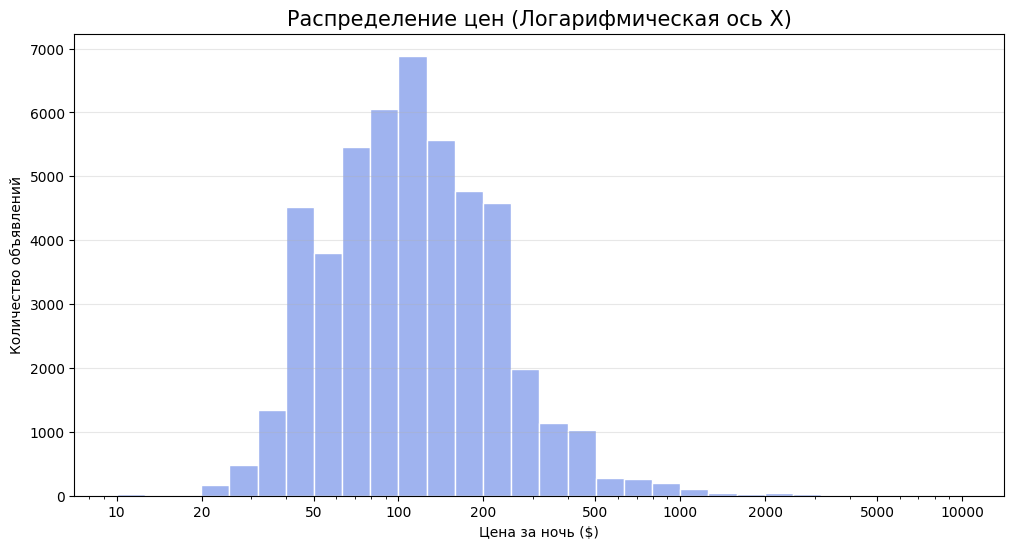

In [23]:
plt.figure(figsize=(12, 6))

# Ограничим до 1000$
filtered_data = df[df['price'] < 1000]

sns.histplot(data=df, x='price', bins=30, log_scale=True, 
             kde=True, color='royalblue', edgecolor='white')

# Настраиваем подписи, чтобы они были в реальных долларах
# Мы вручную указываем, какие значения цен хотим видеть на шкале
ticks = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
plt.xticks(ticks, labels=ticks)

plt.title('Распределение цен (Логарифмическая ось X)', fontsize=15)
plt.xlabel('Цена за ночь ($)')
plt.ylabel('Количество объявлений')
plt.grid(axis='y', alpha=0.3)

plt.show()

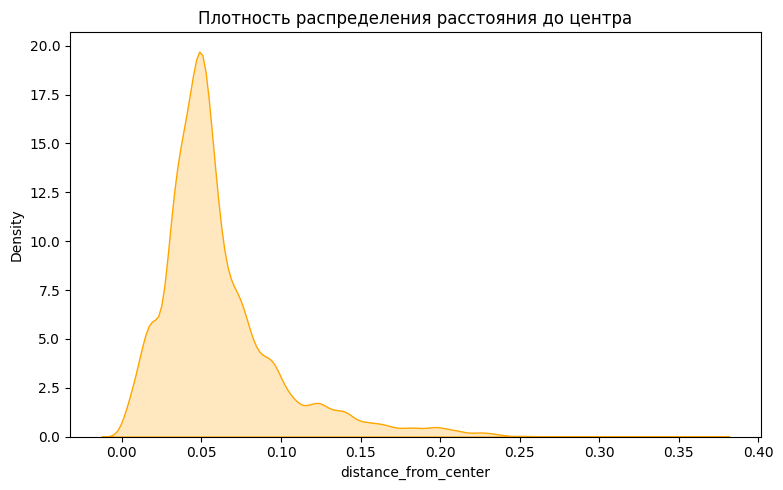

In [24]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 2)
sns.kdeplot(df['distance_from_center'], fill=True, color='orange')
plt.title('Плотность распределения расстояния до центра')

plt.tight_layout()
plt.show()

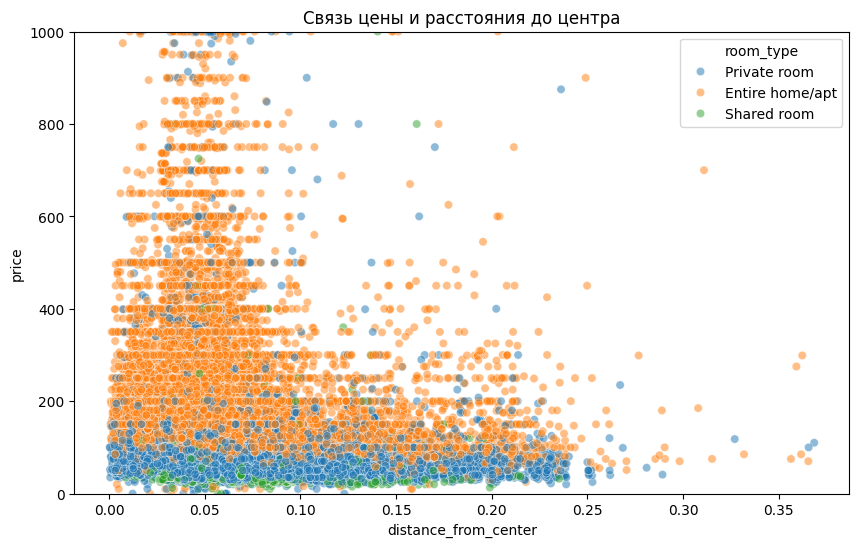

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance_from_center', y='price', hue='room_type', alpha=0.5)
plt.ylim(0, 1000)
plt.title('Связь цены и расстояния до центра')
plt.show()

отсюда сразу два наблюдения
1) если выбросить "одинокие точки", цена падает при удалении от центра
2) чем больше комнат, тем больше цена (удивительно)

ValueError: Could not interpret value `price_log` for `x`. An entry with this name does not appear in `data`.

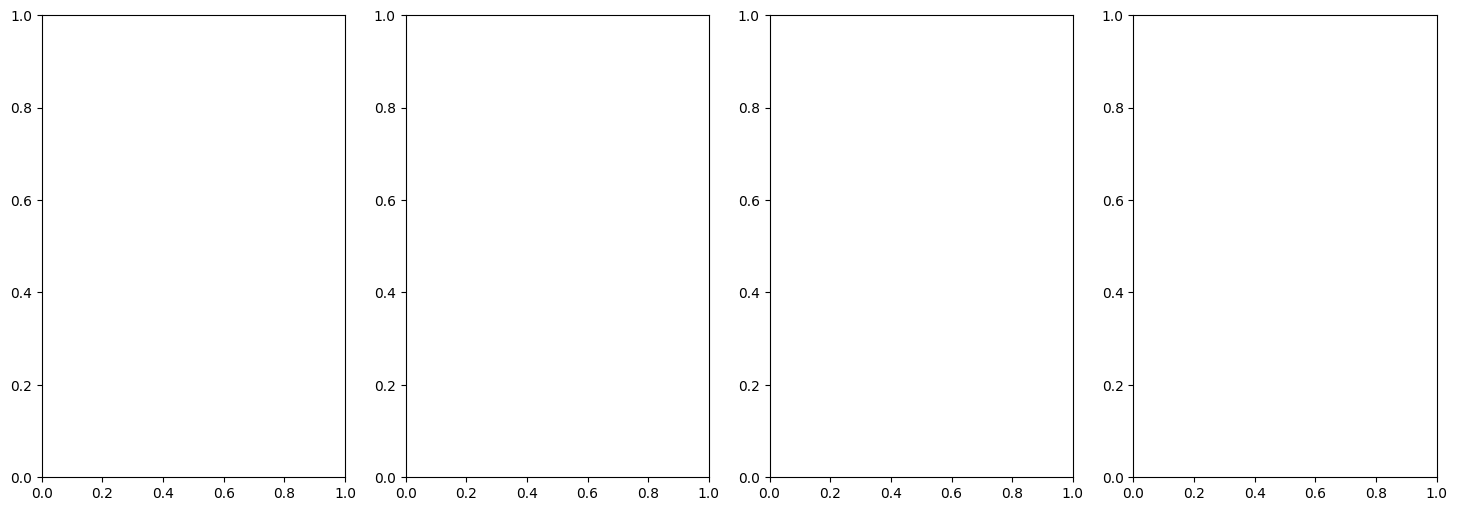

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# 1. Boxplot для цены (логарифм)
sns.boxplot(data=df, x='price_log', ax=axes[0], color='salmon')
axes[0].set_title('Boxplot: Price (Log scale)')
axes[0].set_ylabel('Log(Price)')

# 2. Boxplot для минимального количества ночей
# Ограничим до 30 ночей
sns.boxplot(data=df, x='minimum_nights', ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot: Minimum Nights')
axes[1].set_ylabel('Nights')
# Ограничим до 15 ночей
sns.boxplot(data=df[df['minimum_nights'] <= 15], x='minimum_nights', ax=axes[2], color='skyblue')
axes[2].set_title('Boxplot: Minimum Nights (up to 15)')
axes[2].set_ylabel('Nights')

# 3. Boxplot для количества отзывов
sns.boxplot(data=df, x='number_of_reviews', ax=axes[3], color='lightgreen')
axes[3].set_title('Boxplot: Number of Reviews')
axes[3].set_ylabel('Reviews')

plt.tight_layout()
plt.show()

1) есть аномально высокие и низкие, в целом нормально
2) большинство минимумов ночей до 4, но есть аномально высокие значения
3) тоже есть места с большим числом отзывов (100+), но большинство <20

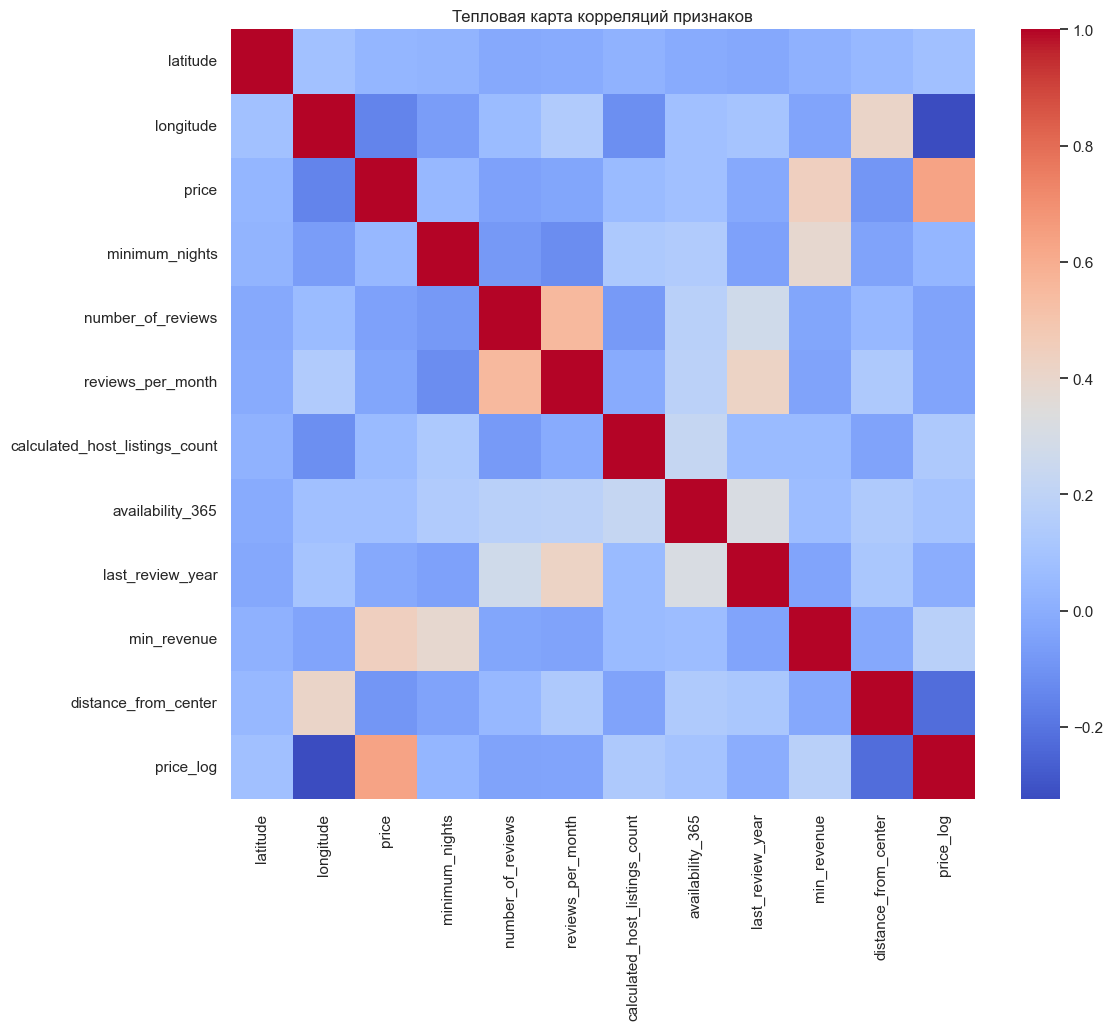

In [ ]:
#heatmap для поиска корреляций
numeric_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляций признаков')
plt.show()

наблюдаем корелляцию :
number_of_reviews, reviews_per_month, last_review_year
price_log и price (кто бы мог подумать:)
distance_from_center и longtitude (а вот latitude - не особо)
думаю связано с тем как расположен Манхэттен и остальные районы на карте
longtitude и privce_log - отрицательная корелляция (та же причина)


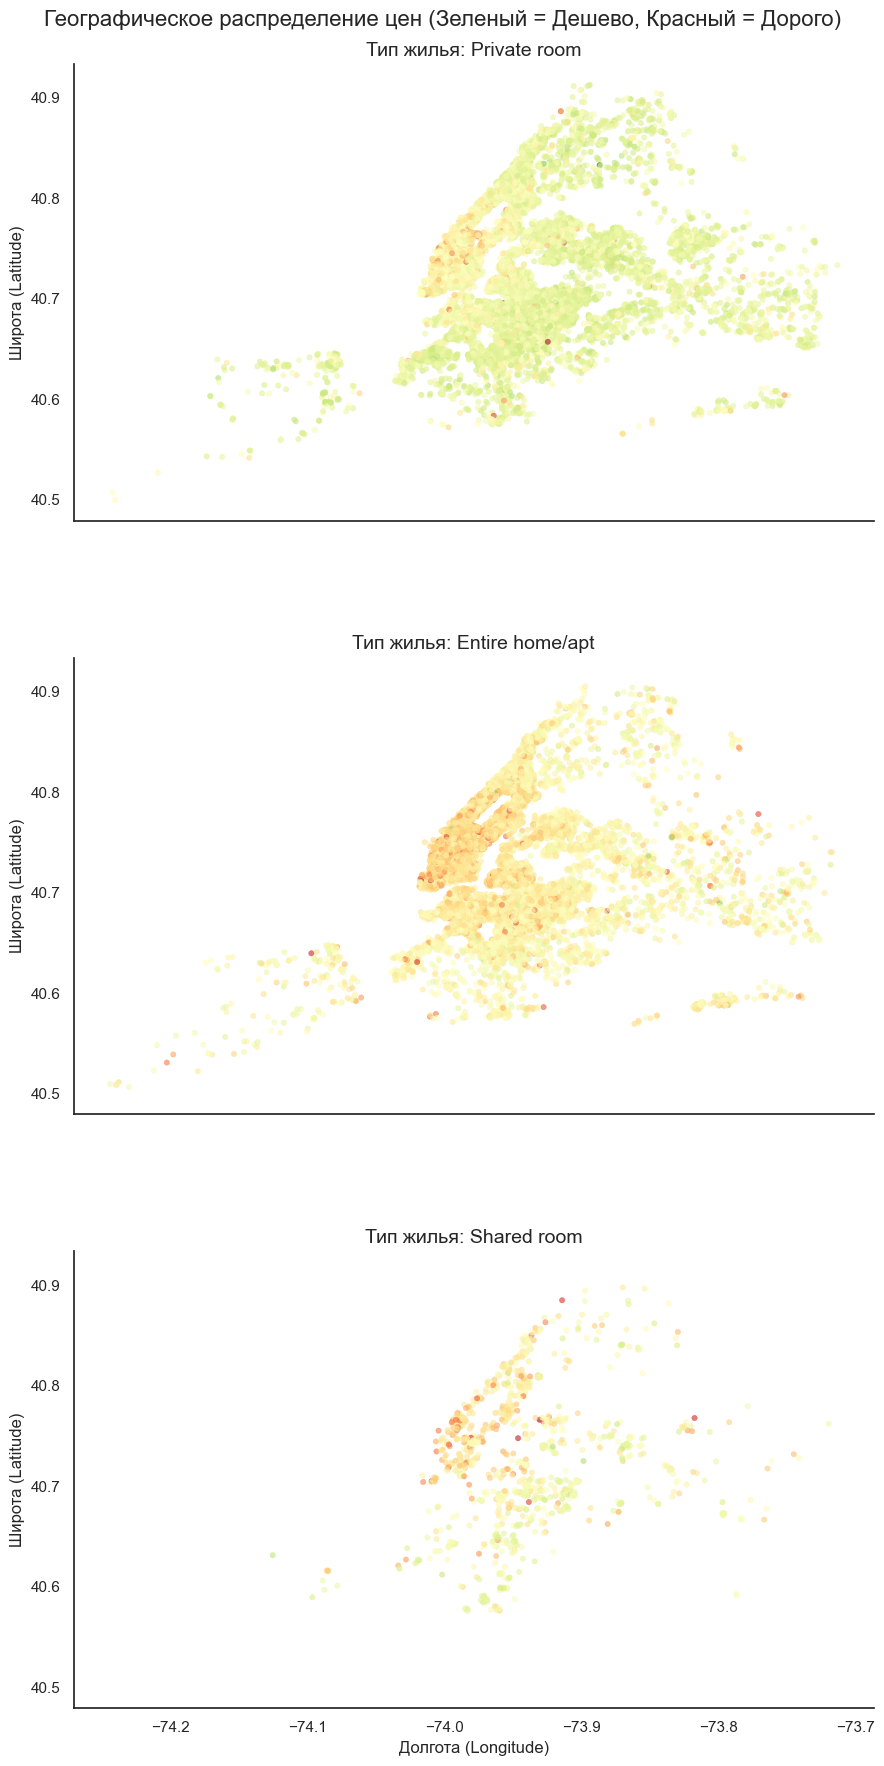

In [ ]:
sns.set_theme(style="white")

g = sns.FacetGrid(df, 
                  col="room_type", 
                  col_wrap=1, 
                  height=6, 
                  aspect=1.5)

g.map_dataframe(sns.scatterplot, 
                x="longitude", 
                y="latitude", 
                hue="price_log", 
                palette="RdYlGn_r", 
                alpha=0.6, 
                edgecolor=None, 
                s=15)

g.set_axis_labels("Долгота (Longitude)", "Широта (Latitude)")
g.set_titles(col_template="Тип жилья: {col_name}", size=14)

plt.subplots_adjust(hspace=0.3, top=0.95)
g.fig.suptitle('Географическое распределение цен (Зеленый = Дешево, Красный = Дорого)', fontsize=16)

plt.show()

Выводы...
1) общий анализ - имеется значительный разброс по некоторым колонкам, но логически все значения находятся в допустимых пределах
2) цены - если логарифмировать шкалу, распределение близко к нормальному
3) расстояние до центра тоже 
4) цена обратно пропорцианальна расстоянию до центра
5) чем больше комнат, тем выше цена
6) манхэттен - самый дорогой район
7) shared room популярны только поблизости от центра - опять же связано с ценой

думаю на этом датасете можно было бы обучить линейную модель по определению рыночной стоимости некоторого номера на основании информации и нем